Initialize

In [1]:
import torch
import random

from environment import Wrapper
from memory_replay import MemoryReplay
from networks import Actor, Cretic
from tool_function import Tool


device = Tool.get_gpu()
print(f"Using device: {device}")
env = Wrapper()
memory = MemoryReplay(20000, device)

actor = Actor(3, 128).to(device)
actor_delay = Actor(3, 128).to(device)
actor_delay.load_state_dict(actor.state_dict())
Tool.requires_grad(actor_delay, False)

cretic = Cretic(4, 128).to(device)
cretic_target = Cretic(4, 128).to(device)
cretic_target.load_state_dict(cretic.state_dict())
Tool.requires_grad(cretic_target, False)

actorLR = 5e-4
creticLR = 5e-3
optimizer_actor = torch.optim.Adam(actor.parameters(), lr=actorLR)
optimizer_cretic = torch.optim.Adam(cretic.parameters(), lr=creticLR)

Using device: cuda


Main Functions

In [2]:
def play():
    data = []
    reward_sum = 0

    state = env.reset()
    over = False
    while not over:
        state_tensor = torch.FloatTensor(state).reshape(1, 3).to(device)
        action = actor(state_tensor).item()
        # add noise
        action += random.normalvariate(mu=0, sigma=0.2)

        next_state, reward, over = env.step(action)

        data.append((state, action, reward, next_state, over))
        reward_sum += reward

        state = next_state

    return data, reward_sum


def train_actor(state):
    Tool.requires_grad(actor, True)
    Tool.requires_grad(cretic, False)

    action = actor(state)

    input = torch.cat([state, action], dim=1)
    loss = -cretic_target(input).mean()

    loss.backward()
    optimizer_actor.step()
    optimizer_actor.zero_grad()

    return loss.item()


def train_cretic(state, action, reward, next_state, over):
    Tool.requires_grad(actor, False)
    Tool.requires_grad(cretic, True)

    input = torch.cat([state, action], dim=1)
    value = cretic(input)

    with torch.no_grad():
        next_action = actor_delay(next_state)
        input = torch.cat([next_state, next_action], dim=1)
        target = cretic_target(input)
    target = target * 0.99 * (1 - over) + reward

    loss = torch.nn.functional.mse_loss(value, target)

    loss.backward()
    optimizer_cretic.step()
    optimizer_cretic.zero_grad()

    return loss.item(), value.mean().item()

Train

In [3]:
# make model training mode
actor.train()
cretic.train()

epochs_list = []
rewards_list = []

# train loop
for epoch in range(200):
    old_len = len(memory)
    while len(memory) - old_len < 200 and len(memory) != 20000:
        memory.push(play()[0])

    for i in range(200):
        state, action, reward, next_state, over = memory.sample(128)

        train_actor(state)
        _, value = train_cretic(state, action, reward, next_state, over)

        Tool.soft_update(actor, actor_delay)
        Tool.soft_update(cretic, cretic_target)

    if epoch % 20 == 0:
        test_result = sum([play()[1] for _ in range(20)]) / 20
        print(f"Epoch: {epoch} | Memory: {len(memory)} | Value: {value:.4f} | Test Reward: {test_result:.4f}")

        epochs_list.append(epoch)
        rewards_list.append(test_result)

env.close()

Epoch: 0 | Memory: 200 | Value: -13.1037 | Test Reward: -1488.7342
Epoch: 20 | Memory: 4200 | Value: -68.9571 | Test Reward: -196.1146
Epoch: 40 | Memory: 8200 | Value: -35.8592 | Test Reward: -152.2556
Epoch: 60 | Memory: 12200 | Value: -39.1536 | Test Reward: -147.2956
Epoch: 80 | Memory: 16200 | Value: -32.8325 | Test Reward: -156.8702
Epoch: 100 | Memory: 20000 | Value: -27.7334 | Test Reward: -176.6309
Epoch: 120 | Memory: 20000 | Value: -24.1647 | Test Reward: -199.7269
Epoch: 140 | Memory: 20000 | Value: -28.5066 | Test Reward: -164.5948
Epoch: 160 | Memory: 20000 | Value: -25.7490 | Test Reward: -151.0470
Epoch: 180 | Memory: 20000 | Value: -26.7233 | Test Reward: -171.9897


Result

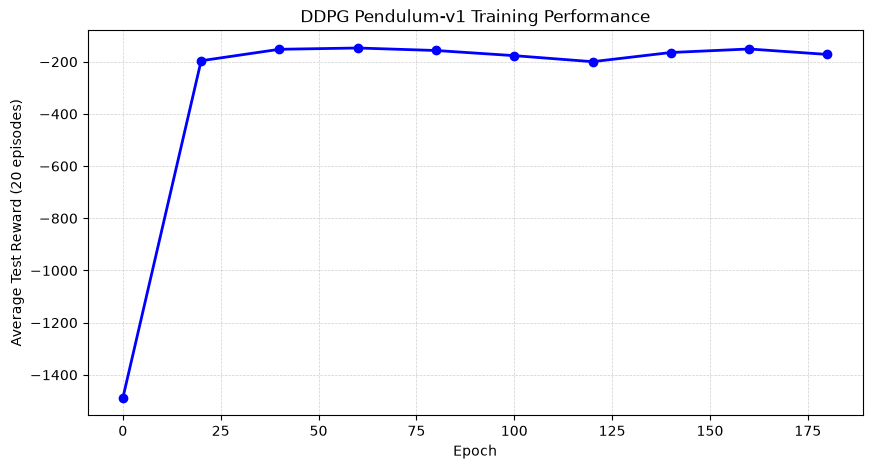

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(epochs_list, rewards_list, marker='o', color='b', linestyle='-', linewidth=2)
plt.title('DDPG on Pendulum-v1')
plt.xlabel('Epoch')
plt.ylabel('Average Test Reward (20 episodes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()